In [1]:
from tools import VideoProcessor, PedestrianDetectionModel, PoseEstimationModel
import matplotlib.pyplot as plt
import cv2

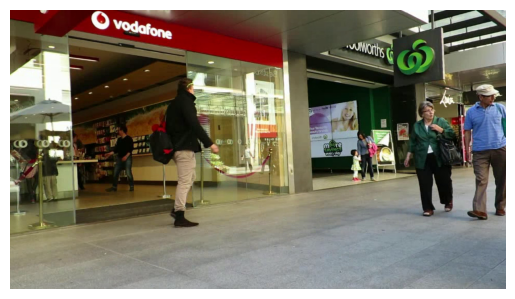

In [2]:
VIDEO_PATH = "inputs/video-data-mot/MOT17-09-SDP-raw.webm"
video_processor = VideoProcessor(VIDEO_PATH)
image = video_processor.get_frame(60)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


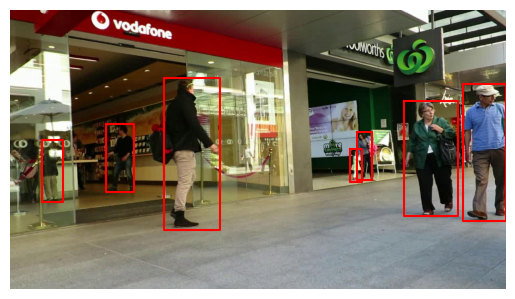

In [3]:
detection_model = PedestrianDetectionModel()
batched_detections = detection_model.get_detections(image)

for detection in batched_detections:
    for box in detection.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'r')

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


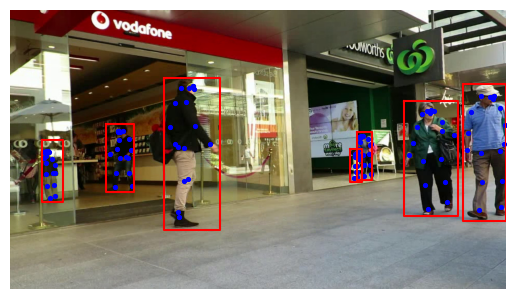

In [4]:
pose_estimation_model = PoseEstimationModel()

for detection in batched_detections:
    for box in detection.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cropped_person = image[y1:y2, x1:x2]
        pose = pose_estimation_model.estimate_pose(cropped_person)
        # draw the detection and the pose on the image 
        plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'r')
        # Extract all keypoints and adjust to original image coordinates
        if pose['keypoints']:
            keypoints_x = [kp[0] + x1 for kp in pose['keypoints']]
            keypoints_y = [kp[1] + y1 for kp in pose['keypoints']]
            plt.scatter(keypoints_x, keypoints_y, c='blue', marker='.', s=30)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()